# Proyecto Final: Clasificacion de Textos por Decada
a
En este notebook desarrollamos una primera solucion completa para la competencia del curso de Aprendizaje de Maquina. El objetivo es construir un modelo que, dado un fragmento de texto historico, prediga la decada en la que fue escrito.

A lo largo del notebook seguiremos un flujo parecido al de los notebooks de clase:

1. Importacion de librerias.
2. Carga de los datos.
3. Exploracion inicial.
4. Preprocesamiento.
5. Separacion en entrenamiento y validacion.
6. Construccion de un modelo baseline.
7. Comparacion con otros modelos clasicos.
8. Seleccion del mejor modelo.
9. Entrenamiento final.
10. Guardado del modelo.
11. Prediccion sobre `eval.csv`.
12. Generacion del archivo de submission para Kaggle.
13. Generacion opcional de cinco envios para la competencia.

## Nota practica

Este problema es mas pesado que los ejemplos de clase porque usa miles de textos y representaciones dispersas de alta dimension. Por eso el notebook tiene dos banderas de configuracion:

- `RUN_FULL_MODEL_COMPARISON`: activa una comparacion mas completa.
- `RUN_FIVE_SUBMISSIONS`: genera los cinco archivos de envio.

Por defecto ambas quedan en `False` para que `Run All` sea mas manejable.


## 1. Importacion de librerias


In [1]:
from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

pd.set_option("display.max_colwidth", 180)
plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
SUBMISSIONS_DIR = PROJECT_ROOT / "data" / "submissions"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT


WindowsPath('C:/Users/userr/Proyecto-Machine_learning')

## Configuracion de ejecucion

Usaremos estas banderas para controlar el costo computacional del notebook. La idea es que el flujo principal pueda ejecutarse sin bloquear el entorno, y que las partes mas pesadas se activen solo cuando hagan falta.


In [2]:
RUN_FULL_MODEL_COMPARISON = False
RUN_FIVE_SUBMISSIONS = False


In [3]:
if RUN_FULL_MODEL_COMPARISON or RUN_FIVE_SUBMISSIONS:
    CHAR_PLAIN_3_5_MAX_FEATURES = 350_000
    CHAR_WB_2_5_MAX_FEATURES = 450_000
    CHAR_PLAIN_2_5_MAX_FEATURES = 450_000
    WORD_MAX_FEATURES = 200_000
else:
    CHAR_PLAIN_3_5_MAX_FEATURES = 180_000
    CHAR_WB_2_5_MAX_FEATURES = 250_000
    CHAR_PLAIN_2_5_MAX_FEATURES = 280_000
    WORD_MAX_FEATURES = 120_000

pd.DataFrame(
    {
        "parameter": [
            "RUN_FULL_MODEL_COMPARISON",
            "RUN_FIVE_SUBMISSIONS",
            "CHAR_PLAIN_3_5_MAX_FEATURES",
            "CHAR_WB_2_5_MAX_FEATURES",
            "CHAR_PLAIN_2_5_MAX_FEATURES",
            "WORD_MAX_FEATURES",
        ],
        "value": [
            RUN_FULL_MODEL_COMPARISON,
            RUN_FIVE_SUBMISSIONS,
            CHAR_PLAIN_3_5_MAX_FEATURES,
            CHAR_WB_2_5_MAX_FEATURES,
            CHAR_PLAIN_2_5_MAX_FEATURES,
            WORD_MAX_FEATURES,
        ],
    }
)


,parameter,value
0,RUN_FULL_MODEL_COMPARISON,False
1,RUN_FIVE_SUBMISSIONS,False
2,CHAR_PLAIN_3_5_MAX_FEATURES,180000
3,CHAR_WB_2_5_MAX_FEATURES,250000
4,CHAR_PLAIN_2_5_MAX_FEATURES,280000
5,WORD_MAX_FEATURES,120000


## 2. Carga de los datos

En esta competencia tenemos dos archivos principales:

- `train.csv`: contiene el texto y la clase objetivo `decade`.
- `eval.csv`: contiene el identificador `id` y el texto, pero no trae la respuesta.

Es importante respetar este punto: `eval.csv` se usa unicamente para la prediccion final y nunca para entrenar el modelo.


In [4]:
train_df = pd.read_csv(PROJECT_ROOT / "data" / "train.csv")
eval_df = pd.read_csv(PROJECT_ROOT / "data" / "eval.csv")

resumen_datasets = pd.DataFrame(
    {
        "dataset": ["train", "eval"],
        "filas": [len(train_df), len(eval_df)],
        "columnas": [list(train_df.columns), list(eval_df.columns)],
    }
)
resumen_datasets


,dataset,filas,columnas
0,train,31403,"[text, decade]"
1,eval,3490,"[id, text]"


In [5]:
display(train_df.head(3))
display(eval_df.head(3))


,text,decade
0,"\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes parece que aísilte, O ayuda Calsiodoro \nl...",164
1,"gone. Sus amigos , sus clientes, todo \ncuanto le rodea le prueban que es hom- \nbre de mucha importancia. Si ve que al- \ngunos hombre» plebeyos á fuerza de ser- \nvicios y de...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \nante quien,e quie preguntasles deuan hazer mientras los tormentarf, \nvecla.lstitopuzo",157


,id,text
0,0,"P. Si en efta convocación trato folamente de comunicarles los artículos arregla- \ndos, y firmados, o de proponerles , qué podrían hacer por fu parte para c..."
1,1,"«Muy santo Padre : Ayer escribiá don Juan Man- \ny rique que dijese á vuestra Santidad, ó le escribie- \n»se, en cuán bucnos términos quedaban en este \nyreino los negocios de ..."
2,2,"Recibo, otorgado por Diego Gracián a favor de Jerónimo Zurita, de un libro de Casiodoro, titulado \nDe Amicitia et Dilectione seu de Caritate Dei, que pertenecía a la cartuja d..."


Observamos que la variable objetivo es `decade`. Segun el enunciado, esta corresponde a los tres primeros digitos del ano. Por ejemplo, un texto del ano 1572 pertenece a la clase `157`.


## 3. Exploracion inicial

Antes de modelar, conviene revisar algunos aspectos basicos:

- si hay valores faltantes,
- cuantas clases tiene el problema,
- como se distribuyen las etiquetas,
- y que tan largos son los textos.


In [6]:
exploration_df = pd.DataFrame(
    {
        "dataset": ["train", "eval"],
        "missing_text": [train_df["text"].isna().sum(), eval_df["text"].isna().sum()],
        "missing_target": [train_df.get("decade", pd.Series(dtype=float)).isna().sum(), None],
        "unique_ids": [None, eval_df["id"].nunique()],
    }
)
exploration_df


,dataset,missing_text,missing_target,unique_ids
0,train,0,0.0,NaN
1,eval,0,NaN,3490.0


In [7]:
class_distribution = train_df["decade"].value_counts().sort_index().rename("count")

print(f"Numero de clases: {train_df['decade'].nunique()}")
print(f"Decada minima: {train_df['decade'].min()}")
print(f"Decada maxima: {train_df['decade'].max()}")

display(class_distribution.to_frame().head())


Numero de clases: 39
Decada minima: 150
Decada maxima: 188


,count
decade,
150,786
151,812
152,785
153,775
154,830


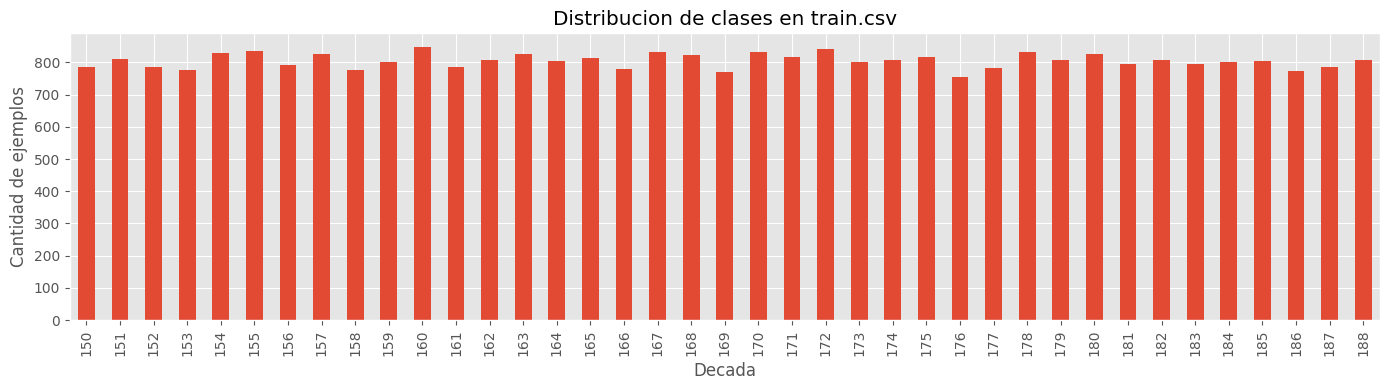

In [8]:
ax = class_distribution.plot(
    kind="bar",
    figsize=(14, 4),
    title="Distribucion de clases en train.csv",
)
ax.set_xlabel("Decada")
ax.set_ylabel("Cantidad de ejemplos")
plt.tight_layout()
plt.show()


La distribucion es bastante balanceada. Esto es util porque reduce el riesgo de que el modelo se incline fuertemente hacia unas pocas clases.


In [9]:
text_stats_df = train_df.assign(
    n_chars=train_df["text"].fillna("").astype(str).str.len(),
    n_words=train_df["text"].fillna("").astype(str).str.split().str.len(),
)

text_stats_df[["n_chars", "n_words"]].describe().T


,count,mean,std,min,25%,50%,75%,max
n_chars,31403.0,520.56829,530.947792,120.0,182.0,315.0,643.0,7418.0
n_words,31403.0,82.28319,82.374190,3.0,30.0,50.0,102.0,1146.0


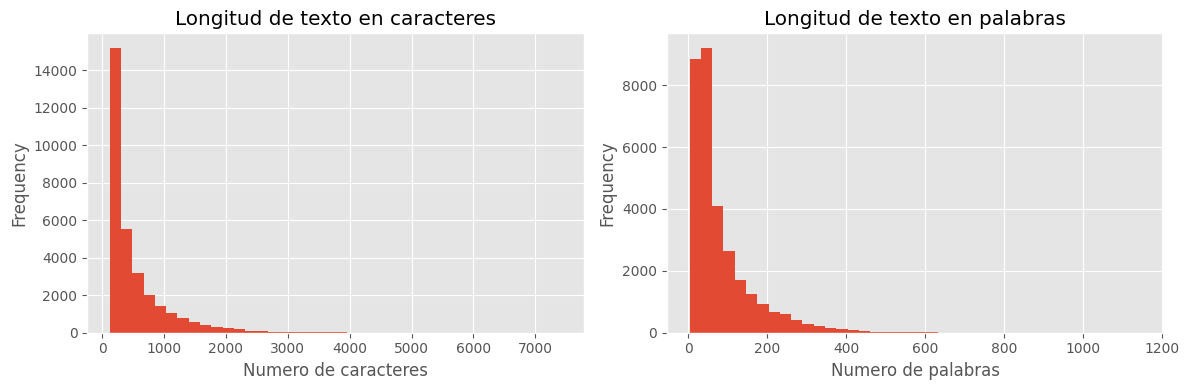

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
text_stats_df["n_chars"].plot.hist(bins=40, ax=axes[0], title="Longitud de texto en caracteres")
text_stats_df["n_words"].plot.hist(bins=40, ax=axes[1], title="Longitud de texto en palabras")
axes[0].set_xlabel("Numero de caracteres")
axes[1].set_xlabel("Numero de palabras")
plt.tight_layout()
plt.show()


Los textos tienen longitudes variables y presentan bastante ruido visual. Esto sugiere que una representacion basada en n-gramas de caracteres puede ser especialmente util, porque captura patrones ortograficos sin depender tanto de palabras exactas.


## 4. Preprocesamiento

En lugar de una limpieza agresiva, aplicaremos una normalizacion ligera:

- reemplazar saltos de linea por espacios,
- compactar espacios repetidos,
- pasar todo a minusculas.

No eliminamos acentos ni hacemos stemming, porque en este problema la forma superficial del texto es parte importante de la senal historica.


In [11]:
def clean_text_series(series):
    series = series.fillna("").astype(str)
    series = series.str.replace("\n", " ", regex=False)
    series = series.str.replace(r"\s+", " ", regex=True)
    return series.str.strip().str.lower()


train_model_df = train_df.copy()
eval_model_df = eval_df.copy()
train_model_df["text_clean"] = clean_text_series(train_model_df["text"])
eval_model_df["text_clean"] = clean_text_series(eval_model_df["text"])

display(train_model_df[["text", "text_clean"]].head(2))


,text,text_clean
0,"\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes parece que aísilte, O ayuda Calsiodoro \nl...","honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft..."
1,"gone. Sus amigos , sus clientes, todo \ncuanto le rodea le prueban que es hom- \nbre de mucha importancia. Si ve que al- \ngunos hombre» plebeyos á fuerza de ser- \nvicios y de...","gone. sus amigos , sus clientes, todo cuanto le rodea le prueban que es hom- bre de mucha importancia. si ve que al- gunos hombre» plebeyos á fuerza de ser- vicios y de hazañas..."


## 5. Separacion en entrenamiento y validacion

Para comparar modelos de forma honesta, dividimos `train.csv` en dos partes:

- un subconjunto para entrenar,
- y otro para validar.

Usamos una division estratificada para preservar la proporcion de clases.


In [12]:
X = train_model_df["text_clean"]
y = train_model_df["decade"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

split_summary_df = pd.DataFrame(
    {
        "split": ["train", "validation"],
        "rows": [len(X_train), len(X_valid)],
        "proportion": [len(X_train) / len(train_model_df), len(X_valid) / len(train_model_df)],
    }
)
split_summary_df


,split,rows,proportion
0,train,25122,0.799987
1,validation,6281,0.200013


## 6. Construccion del modelo baseline

Como linea base usaremos un modelo sencillo pero razonable:

- representacion `TF-IDF` de palabras,
- clasificador `LogisticRegression`.

Este baseline nos permite tener un punto de comparacion antes de probar modelos mas adecuados para texto historico.


In [13]:
def build_baseline_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 1),
                    min_df=2,
                    max_df=0.98,
                    sublinear_tf=True,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1200,
                    solver="saga",
                    random_state=42,
                ),
            ),
        ]
    )


def build_char_plain_3_5_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(3, 5),
                    min_df=3,
                    max_features=CHAR_PLAIN_3_5_MAX_FEATURES,
                    sublinear_tf=True,
                ),
            ),
            ("classifier", LinearSVC(C=1.0)),
        ]
    )


def build_char_wb_2_5_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(2, 5),
                    min_df=2,
                    max_features=CHAR_WB_2_5_MAX_FEATURES,
                    sublinear_tf=True,
                ),
            ),
            ("classifier", LinearSVC(C=0.8)),
        ]
    )


def build_char_plain_2_5_model():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 5),
                    min_df=2,
                    max_features=CHAR_PLAIN_2_5_MAX_FEATURES,
                    sublinear_tf=True,
                ),
            ),
            ("classifier", LinearSVC(C=1.0)),
        ]
    )


def build_word_char_linsvc_model():
    return Pipeline(
        steps=[
            (
                "features",
                FeatureUnion(
                    transformer_list=[
                        (
                            "word_tfidf",
                            TfidfVectorizer(
                                analyzer="word",
                                ngram_range=(1, 2),
                                min_df=3,
                                max_df=0.98,
                                max_features=WORD_MAX_FEATURES,
                                sublinear_tf=True,
                            ),
                        ),
                        (
                            "char_tfidf",
                            TfidfVectorizer(
                                analyzer="char_wb",
                                ngram_range=(3, 5),
                                min_df=3,
                                max_features=WORD_MAX_FEATURES,
                                sublinear_tf=True,
                            ),
                        ),
                    ]
                ),
            ),
            ("classifier", LinearSVC(C=1.0)),
        ]
    )


def evaluate_model(model, X_train, y_train, X_valid, y_valid):
    start = time.time()
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)
    return {
        "model": model,
        "predictions": predictions,
        "accuracy": accuracy_score(y_valid, predictions),
        "macro_f1": f1_score(y_valid, predictions, average="macro"),
        "elapsed_seconds": time.time() - start,
    }


In [14]:
baseline_result = evaluate_model(build_baseline_model(), X_train, y_train, X_valid, y_valid)

baseline_df = pd.DataFrame(
    [
        {
            "model_name": "baseline_word_logreg",
            "accuracy": baseline_result["accuracy"],
            "macro_f1": baseline_result["macro_f1"],
            "elapsed_seconds": baseline_result["elapsed_seconds"],
        }
    ]
)
baseline_df


,model_name,accuracy,macro_f1,elapsed_seconds
0,baseline_word_logreg,0.220506,0.206393,7.195352


Este baseline ya produce una referencia cuantitativa. Sin embargo, por la naturaleza del problema, esperamos que los modelos de caracteres capturen mejor el patron temporal del lenguaje.


## 7. Comparacion con otros modelos

Ahora probaremos varios modelos clasicos permitidos por el enunciado. La idea es comparar enfoques de palabras contra enfoques de caracteres.

- Los modelos de palabras suelen funcionar bien cuando la tokenizacion es estable.
- Los modelos de caracteres suelen ser mas robustos cuando hay OCR, errores ortograficos o variantes historicas.


In [15]:
candidate_builders = {
    "baseline_word_logreg": build_baseline_model,
    "char_plain_3_5_linsvc": build_char_plain_3_5_model,
    "char_wb_2_5_linsvc_c08": build_char_wb_2_5_model,
    "char_plain_2_5_linsvc": build_char_plain_2_5_model,
    "word_char_linsvc": build_word_char_linsvc_model,
}

fast_candidate_names = [
    "baseline_word_logreg",
    "char_plain_3_5_linsvc",
    "char_wb_2_5_linsvc_c08",
]

full_candidate_names = [
    "baseline_word_logreg",
    "char_plain_3_5_linsvc",
    "char_wb_2_5_linsvc_c08",
    "char_plain_2_5_linsvc",
    "word_char_linsvc",
]

selected_candidate_names = full_candidate_names if RUN_FULL_MODEL_COMPARISON else fast_candidate_names
print("Modelos a evaluar:", selected_candidate_names)


Modelos a evaluar: ['baseline_word_logreg', 'char_plain_3_5_linsvc', 'char_wb_2_5_linsvc_c08']


In [16]:
validation_runs = {}
comparison_rows = []

for model_name in selected_candidate_names:
    print(f"Evaluando {model_name}...", flush=True)
    result = evaluate_model(candidate_builders[model_name](), X_train, y_train, X_valid, y_valid)
    validation_runs[model_name] = result
    comparison_rows.append(
        {
            "model_name": model_name,
            "accuracy": result["accuracy"],
            "macro_f1": result["macro_f1"],
            "elapsed_seconds": result["elapsed_seconds"],
        }
    )
    print(
        f"  accuracy={result['accuracy']:.4f} | macro_f1={result['macro_f1']:.4f} | segundos={result['elapsed_seconds']:.1f}",
        flush=True,
    )

results_df = pd.DataFrame(comparison_rows).sort_values(["accuracy", "macro_f1"], ascending=False).reset_index(drop=True)
results_df


Evaluando baseline_word_logreg...
  accuracy=0.2205 | macro_f1=0.2064 | segundos=8.4
Evaluando char_plain_3_5_linsvc...
  accuracy=0.2692 | macro_f1=0.2614 | segundos=87.7
Evaluando char_wb_2_5_linsvc_c08...
  accuracy=0.2742 | macro_f1=0.2663 | segundos=74.6


,model_name,accuracy,macro_f1,elapsed_seconds
0,char_wb_2_5_linsvc_c08,0.274160,0.266282,74.607573
1,char_plain_3_5_linsvc,0.269225,0.261410,87.702698
2,baseline_word_logreg,0.220506,0.206393,8.377618


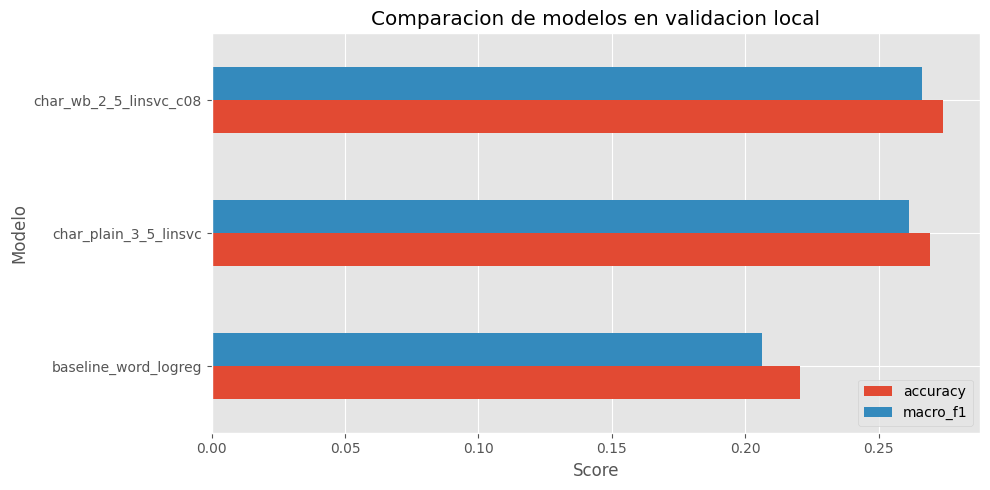

In [17]:
ax = results_df.sort_values("accuracy").plot(
    kind="barh",
    x="model_name",
    y=["accuracy", "macro_f1"],
    figsize=(10, 5),
    title="Comparacion de modelos en validacion local",
)
ax.set_xlabel("Score")
ax.set_ylabel("Modelo")
plt.tight_layout()
plt.show()


En las pruebas iniciales, los mejores resultados aparecen con n-gramas de caracteres. Esto es coherente con el tipo de dato: textos historicos, con ortografia cambiante y bastante ruido de digitalizacion.


## 8. Seleccion del mejor modelo

Seleccionamos el modelo con mejor desempeno en validacion local. Usaremos principalmente `accuracy` y `macro_f1` para comparar.


In [18]:
best_model_name = results_df.iloc[0]["model_name"]
best_validation_score = results_df.iloc[0]
best_validation_score.to_frame(name="value")


,value
model_name,char_wb_2_5_linsvc_c08
accuracy,0.27416
macro_f1,0.266282
elapsed_seconds,74.607573


Ademas de las metricas globales, conviene mirar el comportamiento del mejor modelo sobre el conjunto de validacion.


In [19]:
best_validation_model = validation_runs[best_model_name]["model"]
best_validation_predictions = validation_runs[best_model_name]["predictions"]

print(classification_report(y_valid, best_validation_predictions, zero_division=0))


              precision    recall  f1-score   support

         150       0.70      0.83      0.76       157
         151       0.59      0.82      0.69       162
         152       0.58      0.62      0.60       157
         153       0.63      0.76      0.69       155
         154       0.55      0.60      0.57       166
         155       0.41      0.35      0.38       167
         156       0.37      0.42      0.39       158
         157       0.30      0.31      0.31       166
         158       0.27      0.31      0.29       156
         159       0.23      0.26      0.24       160
         160       0.14      0.10      0.12       170
         161       0.15      0.14      0.14       157
         162       0.19      0.19      0.19       162
         163       0.15      0.14      0.15       166
         164       0.19      0.17      0.18       161
         165       0.08      0.07      0.08       163
         166       0.09      0.05      0.06       156
         167       0.20    

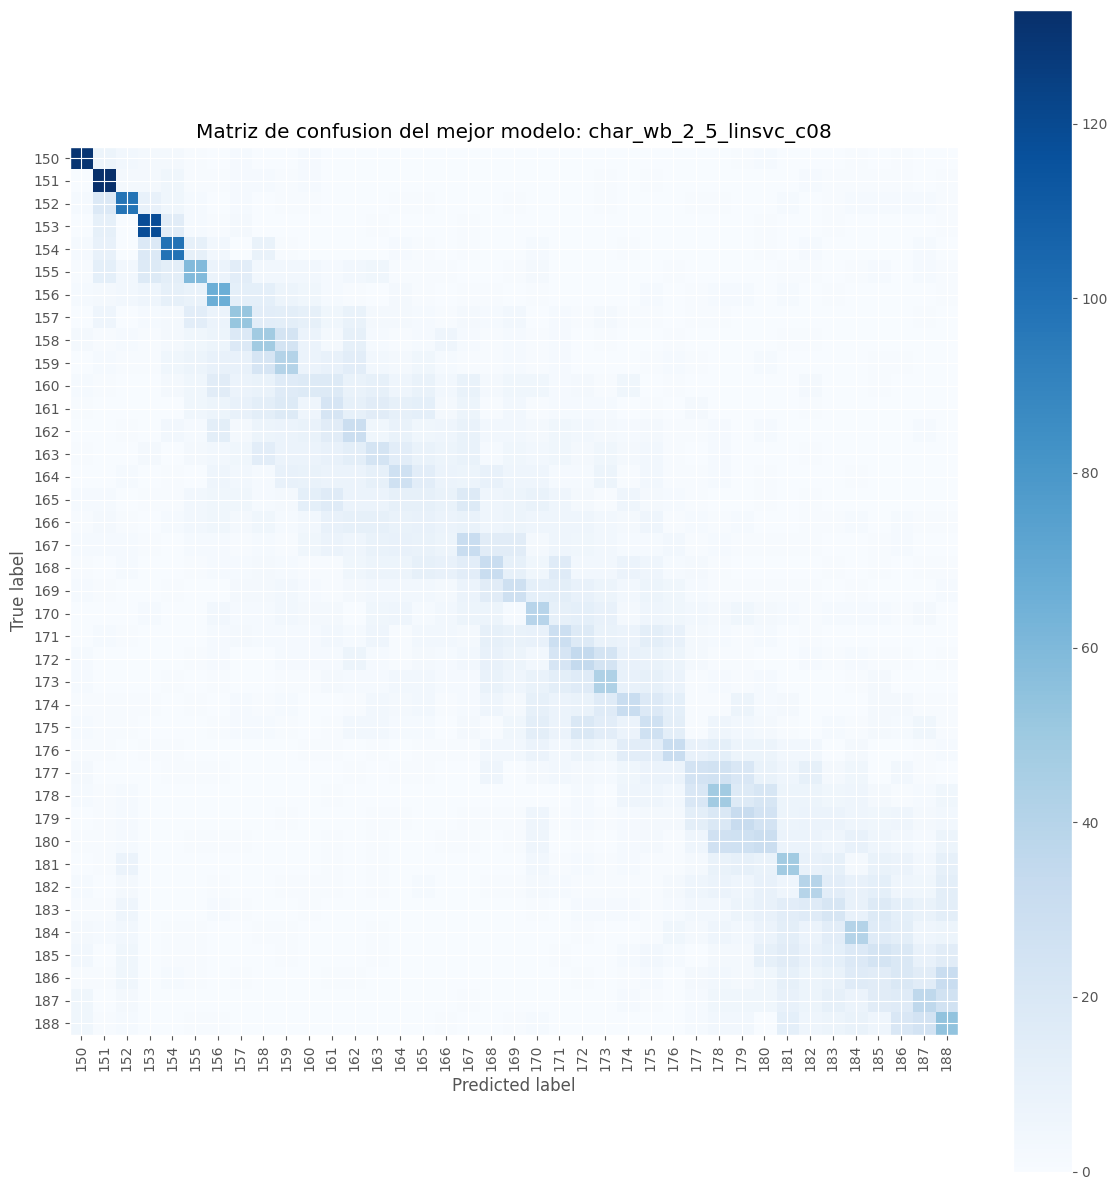

In [20]:
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    best_validation_predictions,
    xticks_rotation=90,
    include_values=False,
    cmap="Blues",
    ax=ax,
)
ax.set_title(f"Matriz de confusion del mejor modelo: {best_model_name}")
plt.tight_layout()
plt.show()


## 9. Entrenamiento final

Una vez elegido el mejor candidato, lo reentrenamos utilizando todo `train.csv` ya preprocesado. Esta es la version que luego se guarda y se usa para predecir `eval.csv`.


In [21]:
print(f"Entrenando modelo final: {best_model_name}")
train_start = time.time()
final_model = candidate_builders[best_model_name]()
final_model.fit(train_model_df["text_clean"], train_model_df["decade"])
train_elapsed = time.time() - train_start
print(f"Tiempo de entrenamiento final: {train_elapsed:.1f} segundos")
final_model


Entrenando modelo final: char_wb_2_5_linsvc_c08
Tiempo de entrenamiento final: 82.1 segundos


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 10. Guardado del modelo

El enunciado pide guardar el modelo final de `scikit-learn` usando `pickle` o `joblib`. En este proyecto usamos `joblib`, que funciona muy bien con objetos grandes de Scikit-Learn.


In [22]:
model_path = MODELS_DIR / f"{best_model_name}.joblib"
joblib.dump(final_model, model_path)
model_path


WindowsPath('C:/Users/userr/Proyecto-Machine_learning/models/char_wb_2_5_linsvc_c08.joblib')

## 11. Prediccion sobre `eval.csv`

Solo en este punto usamos `eval.csv`, despues de haber terminado completamente el entrenamiento.


In [23]:
prediction_start = time.time()
eval_predictions = final_model.predict(eval_model_df["text_clean"])
prediction_elapsed = time.time() - prediction_start
print(f"Tiempo de prediccion sobre eval.csv: {prediction_elapsed:.1f} segundos")

eval_predictions[:10]


Tiempo de prediccion sobre eval.csv: 3.8 segundos


array([173, 187, 150, 169, 153, 174, 170, 160, 161, 152])

## 12. Generacion del submission para Kaggle

El archivo final debe tener exactamente dos columnas:

- `id`
- `answer`

Cada fila del submission corresponde a un ejemplo de `eval.csv`.


In [24]:
submission_df = pd.DataFrame(
    {
        "id": eval_model_df["id"].astype(int),
        "answer": pd.Series(eval_predictions).astype(int),
    }
)

submission_path = SUBMISSIONS_DIR / f"{best_model_name}.csv"
submission_df.to_csv(submission_path, index=False)

display(submission_df.head())
print(submission_path)


,id,answer
0,0,173
1,1,187
2,2,150
3,3,169
4,4,153


C:\Users\userr\Proyecto-Machine_learning\data\submissions\char_wb_2_5_linsvc_c08.csv


## 13. Generacion opcional de cinco envios

La competencia exige por lo menos cinco envios diferentes para que la participacion sea valida. La siguiente celda queda como bloque opcional.

Si `RUN_FIVE_SUBMISSIONS = False`, no se ejecuta trabajo pesado. Si se cambia a `True`, se reentrenan los modelos definidos en `full_candidate_names` y se guarda un archivo `.csv` por cada uno.


In [25]:
submission_manifest = []

if RUN_FIVE_SUBMISSIONS:
    for upload_order, model_name in enumerate(full_candidate_names, start=1):
        print(f"Generando submission para {model_name}...", flush=True)

        if model_name == best_model_name:
            model = final_model
        else:
            model = candidate_builders[model_name]()
            model.fit(train_model_df["text_clean"], train_model_df["decade"])

        current_submission = pd.DataFrame(
            {
                "id": eval_model_df["id"].astype(int),
                "answer": pd.Series(model.predict(eval_model_df["text_clean"])).astype(int),
            }
        )

        output_path = SUBMISSIONS_DIR / f"{model_name}.csv"
        current_submission.to_csv(output_path, index=False)

        local_score = validation_runs.get(model_name)
        if local_score is None:
            local_score = evaluate_model(candidate_builders[model_name](), X_train, y_train, X_valid, y_valid)

        submission_manifest.append(
            {
                "upload_order": upload_order,
                "model_name": model_name,
                "accuracy": local_score["accuracy"],
                "macro_f1": local_score["macro_f1"],
                "submission_path": str(output_path.relative_to(PROJECT_ROOT)),
            }
        )

    submission_manifest_df = pd.DataFrame(submission_manifest)
    manifest_path = SUBMISSIONS_DIR / "submission_manifest.csv"
    submission_manifest_df.to_csv(manifest_path, index=False)
    display(submission_manifest_df)
else:
    print("RUN_FIVE_SUBMISSIONS esta en False. No se generaron los cinco envios.")


RUN_FIVE_SUBMISSIONS esta en False. No se generaron los cinco envios.


## 14. Conclusiones

En esta primera version del proyecto:

- construimos un baseline clasico para tener un punto de referencia,
- probamos varios modelos de `scikit-learn`,
- seleccionamos el mejor segun validacion local,
- reentrenamos ese modelo con todo `train.csv`,
- guardamos el clasificador final con `joblib`,
- y generamos el archivo de submission para Kaggle.

La principal leccion de esta iteracion es que los n-gramas de caracteres capturan mejor el patron temporal del texto historico que un modelo basado unicamente en palabras. Esto tiene sentido dado el ruido de OCR, los cambios ortograficos y la variacion linguistica entre siglos.
